# Supplementary File S5 — Lesson Plan 4: Data Augmentation as Regularization

**Estimated time:** 2.5 hours (2 hr lab + 30 min debrief)
**Prerequisites:** Lesson Plans 1 and 2 (S2, S3); GPU access (~20-40 min total training on a Colab T4, using the resized cache from S1).
**Materials:** `resized_256.zip` in your `CEP_Food_Dataset` Drive folder (built by S1). No Kaggle download and no manual paths needed - the split is rebuilt from the cache below.

## Learning Objectives
- Define data augmentation and implement an augmentation pipeline.
- Compare training and validation accuracy curves with and without augmentation.
- Explain augmentation as a form of regularization that reduces overfitting by expanding the effective training distribution.

---
## Step 0 (10 min): Mount Drive, Extract Cache, Rebuild the Split

This rebuilds the **identical** 70/15/15 split used in S1/S2/S3 (`random_state=42`) so the augmentation comparison is apples-to-apples.

In [2]:
import os, glob, zipfile, random, time
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')
assert os.path.ismount('/content/drive'), "Drive not mounted."

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DRIVE_ROOT  = "/content/drive/MyDrive/CEP_Food_Dataset"
RESIZED_DIR = "/content/resized_256"
LOG_DIR     = f"{DRIVE_ROOT}/aug_logs"       # augmentation logs persist here
os.makedirs(LOG_DIR, exist_ok=True)
print("Device:", DEVICE)

# Pull + extract the resized image cache into its own folder (avoids loose extraction).
def _has_class_dirs(d):
    return os.path.isdir(d) and any(
        os.path.isdir(os.path.join(d, x)) for x in os.listdir(d))

if not _has_class_dirs(RESIZED_DIR):
    zip_matches = glob.glob(f"{DRIVE_ROOT}/**/resized_256.zip", recursive=True)
    assert zip_matches, (
        "resized_256.zip not found under " + DRIVE_ROOT +
        ". Run the S1 pipeline first - it builds this cache.")
    t = time.time()
    with zipfile.ZipFile(sorted(zip_matches, key=os.path.getmtime)[-1]) as z:
        z.extractall(RESIZED_DIR)
    print(f"Extracted cache in {time.time()-t:.0f}s")

# Build (path, label) lists in the SAME class order as S1 (sorted folder names).
class_names, paths, labels = [], [], []
for idx, cls in enumerate(sorted(d for d in os.listdir(RESIZED_DIR)
                                 if os.path.isdir(os.path.join(RESIZED_DIR, d)))):
    class_names.append(cls)
    folder = os.path.join(RESIZED_DIR, cls)
    for f in os.listdir(folder):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            paths.append(os.path.join(folder, f)); labels.append(idx)

NUM_CLASSES = len(class_names)

# Identical stratified 70/15/15 split (only train + val are used in this lesson).
X_tr, X_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.3,
                                            random_state=42, stratify=labels)
X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                              random_state=42, stratify=y_tmp)
print(f"{len(paths):,} images | {NUM_CLASSES} classes | train {len(X_tr):,} | val {len(X_val):,}")

Mounted at /content/drive
Device: cuda
Extracted cache in 4s
4,577 images | 100 classes | train 3,203 | val 687


---
## Step 1 (20 min): Examine Augmented Examples

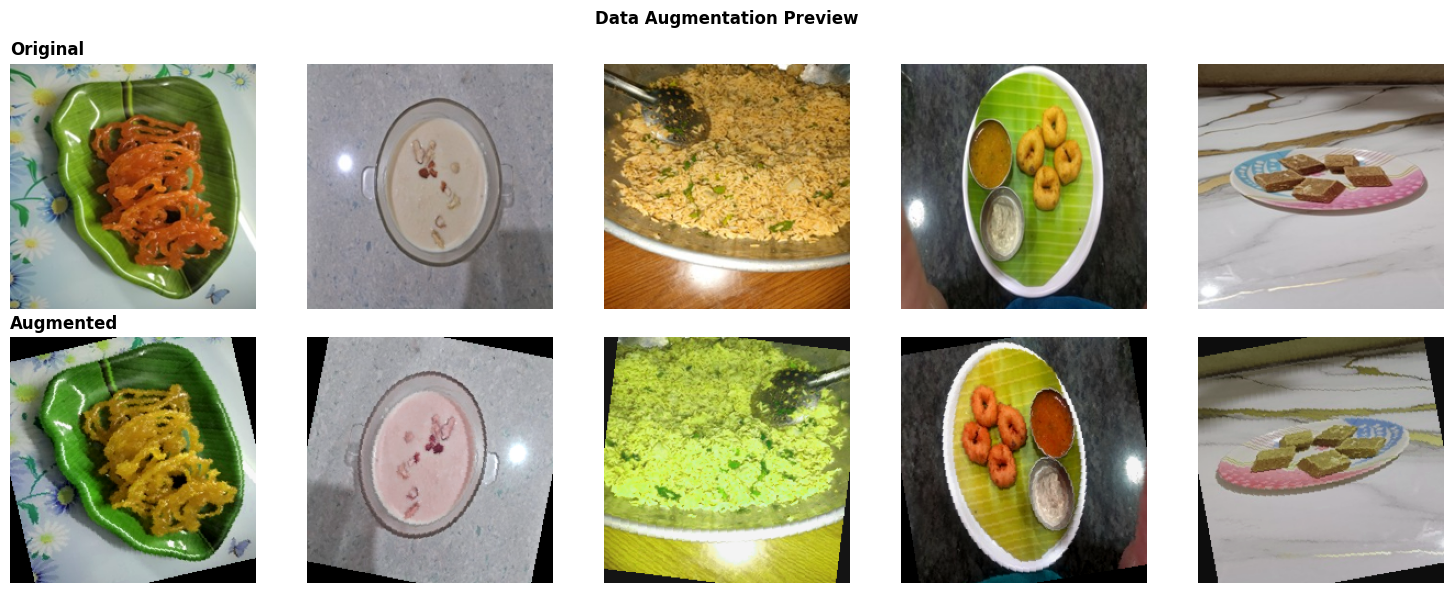

In [3]:
aug_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
])

no_aug_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
])

# Preview: top row = original dishes, bottom row = the same dishes after augmentation.
# Re-run this cell to see fresh random augmentations - the pipeline is stochastic.
sample_paths = []
for cls in random.sample(class_names, min(8, len(class_names))):
    folder = os.path.join(RESIZED_DIR, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        sample_paths.append(os.path.join(folder, random.choice(imgs)))
    if len(sample_paths) == 5:
        break

n = len(sample_paths)
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
axes = np.array(axes).reshape(2, -1)
for i, p in enumerate(sample_paths):
    img = Image.open(p).convert('RGB').resize((224, 224))
    axes[0, i].imshow(img);           axes[0, i].axis('off')
    axes[1, i].imshow(aug_tfm(img));  axes[1, i].axis('off')
axes[0, 0].set_title('Original',  fontweight='bold', loc='left')
axes[1, 0].set_title('Augmented', fontweight='bold', loc='left')
plt.suptitle('Data Augmentation Preview', fontweight='bold')
plt.tight_layout()
plt.show()

**Discussion:**
- Which augmentations (horizontal flip, rotation, colour jitter, crop) preserve the class label for this dataset? Would a *vertical* flip make sense for food photography?
- Are there augmentations that would **not** be appropriate here? (Does flipping or rotating a dish ever change *what dish it is* - e.g. directional garnish placement, text on packaging?)

---
## Step 2 (60 min): Train Two Configurations

Train the ResNet-50 backbone twice on the same split: once **without** augmentation and once **with** the full pipeline (Section 4.2 of the paper). Identical hyperparameters; each run logs its own curves. Logs are saved to Drive **every epoch**, so a disconnect mid-run doesn't lose progress.

In [4]:
class FoodDS(Dataset):
    def __init__(self, paths, labels, geometric_tfm):
        # 'augmentation on/off' is decided purely by which geometric_tfm you pass in.
        self.paths, self.labels = paths, labels
        self.geometric_tfm = geometric_tfm
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        img = self.geometric_tfm(img)
        return self.to_tensor(img), self.labels[i]

EPOCHS     = 30
BATCH_SIZE = 32
LR         = 1e-4

In [5]:
def build_model(n_cls):
    # New torchvision uses the weights= API; fall back to pretrained= on older versions.
    try:
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    except (AttributeError, TypeError):
        m = models.resnet50(pretrained=True)
    m.fc = nn.Linear(m.fc.in_features, n_cls)
    return m.to(DEVICE)

def train_epoch(m, ld, crit, opt, dev):
    m.train()
    ls, cor, tot = 0, 0, 0
    for im, lb in ld:
        im, lb = im.to(dev), lb.to(dev)
        opt.zero_grad()
        o = m(im)
        l = crit(o, lb)
        l.backward()
        opt.step()
        ls += l.item()
        _, p = torch.max(o, 1)
        tot += lb.size(0)
        cor += (p == lb).sum().item()
    return ls/len(ld), 100.*cor/tot

def validate(m, ld, crit, dev):
    m.eval()
    ls, cor, tot = 0, 0, 0
    with torch.no_grad():
        for im, lb in ld:
            im, lb = im.to(dev), lb.to(dev)
            o = m(im)
            ls += crit(o, lb).item()
            _, p = torch.max(o, 1)
            tot += lb.size(0)
            cor += (p == lb).sum().item()
    return ls/len(ld), 100.*cor/tot

def save_log(df, path):
    # Atomic write so a disconnect can't leave a half-written CSV on Drive.
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)

def run_config(run_name, train_geometric_tfm):
    train_ld = DataLoader(FoodDS(X_tr, y_tr, train_geometric_tfm),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_ld   = DataLoader(FoodDS(X_val, y_val, no_aug_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = build_model(NUM_CLASSES)
    crit  = nn.CrossEntropyLoss()
    opt   = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

    hist = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    log_path = os.path.join(LOG_DIR, f"augmentation_log_{run_name}.csv")
    for e in range(1, EPOCHS + 1):
        trl, tra = train_epoch(model, train_ld, crit, opt, DEVICE)
        vl,  va  = validate(model, val_ld, crit, DEVICE)
        for k, v in zip(hist, (e, trl, tra, vl, va)):
            hist[k].append(v)
        save_log(pd.DataFrame(hist), log_path)   # persist after every epoch
        print(f"[{run_name}] Epoch {e}/{EPOCHS} - Train {tra:.2f}% | Val {va:.2f}%")
    print(f"[{run_name}] saved -> {log_path}")
    return pd.DataFrame(hist)

# Run both configurations (this is the ~20-40 min training block).
log_no_aug   = run_config('no_augmentation',   no_aug_tfm)
log_with_aug = run_config('with_augmentation', aug_tfm)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


[no_augmentation] Epoch 1/30 - Train 49.98% | Val 78.02%
[no_augmentation] Epoch 2/30 - Train 86.20% | Val 86.17%
[no_augmentation] Epoch 3/30 - Train 95.22% | Val 88.79%
[no_augmentation] Epoch 4/30 - Train 98.00% | Val 88.21%
[no_augmentation] Epoch 5/30 - Train 99.00% | Val 90.68%
[no_augmentation] Epoch 6/30 - Train 99.38% | Val 90.54%
[no_augmentation] Epoch 7/30 - Train 99.44% | Val 89.67%
[no_augmentation] Epoch 8/30 - Train 99.28% | Val 90.39%
[no_augmentation] Epoch 9/30 - Train 98.97% | Val 87.92%
[no_augmentation] Epoch 10/30 - Train 98.88% | Val 90.10%
[no_augmentation] Epoch 11/30 - Train 98.94% | Val 89.37%
[no_augmentation] Epoch 12/30 - Train 99.22% | Val 89.96%
[no_augmentation] Epoch 13/30 - Train 98.84% | Val 91.41%
[no_augmentation] Epoch 14/30 - Train 98.41% | Val 88.94%
[no_augmentation] Epoch 15/30 - Train 98.47% | Val 88.50%
[no_augmentation] Epoch 16/30 - Train 99.00% | Val 89.67%
[no_augmentation] Epoch 17/30 - Train 98.88% | Val 89.23%
[no_augmentation] Epoch

*(Each run saves its own `augmentation_log_<run_name>.csv` to `CEP_Food_Dataset/aug_logs/`. Together these form the augmentation comparison data referenced in Section 4.2 / Lesson 4 of the paper.)*

---
## Step 3 (30 min): Compare Validation Accuracy Curves

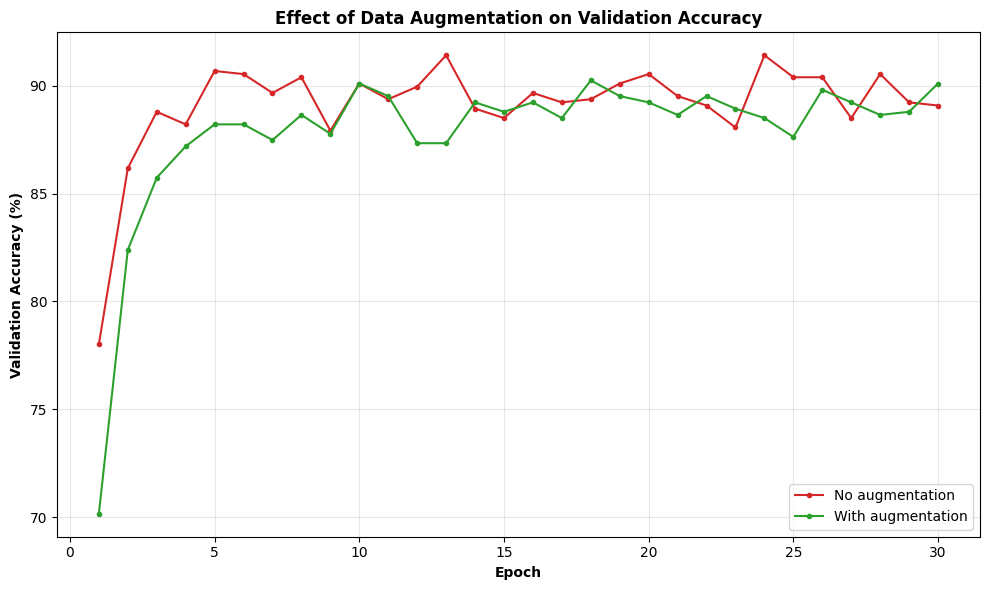

Peak val accuracy -- no augmentation:   91.41%
Peak val accuracy -- with augmentation: 90.25%
Final train-val gap -- no augmentation:   10.01 pp
Final train-val gap -- with augmentation: 8.77 pp


In [6]:
log_no_aug   = pd.read_csv(os.path.join(LOG_DIR, "augmentation_log_no_augmentation.csv"))
log_with_aug = pd.read_csv(os.path.join(LOG_DIR, "augmentation_log_with_augmentation.csv"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(log_no_aug['epoch'],   log_no_aug['val_acc'],   label='No augmentation',   color='tab:red',   marker='o', markersize=3)
ax.plot(log_with_aug['epoch'], log_with_aug['val_acc'], label='With augmentation', color='tab:green', marker='o', markersize=3)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontweight='bold')
ax.set_title('Effect of Data Augmentation on Validation Accuracy', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_no_aug   = log_no_aug['val_acc'].max()
peak_with_aug = log_with_aug['val_acc'].max()
gap_no_aug    = log_no_aug['train_acc'].iloc[-1]   - log_no_aug['val_acc'].iloc[-1]
gap_with_aug  = log_with_aug['train_acc'].iloc[-1] - log_with_aug['val_acc'].iloc[-1]

print(f"Peak val accuracy -- no augmentation:   {peak_no_aug:.2f}%")
print(f"Peak val accuracy -- with augmentation: {peak_with_aug:.2f}%")
print(f"Final train-val gap -- no augmentation:   {gap_no_aug:.2f} pp")
print(f"Final train-val gap -- with augmentation: {gap_with_aug:.2f} pp")

---
## Step 4 (20 min): Interpret Through the Lens of Regularization

Augmentation increases the *effective* training set size and reduces the model's ability to memorize specific training examples - connecting to the formal definition of regularization as a method that reduces variance at the cost of increased bias (Hastie, Tibshirani, and Friedman 2009).

**Discuss:**
- Does the augmented run show a smaller train-val gap than the non-augmented run?
- Does it reach a higher or lower peak validation accuracy?
- How would you explain, to someone unfamiliar with regularization, *why* augmentation reduces overfitting rather than simply adding more distinct data?

---
## Debrief (30 min)

- What other forms of regularization serve a similar purpose (dropout, weight decay, early stopping)?
- How would you decide how much augmentation to apply?
- Could augmentation ever hurt performance? Under what conditions?

---
## Assessment

Design an augmentation pipeline for a different image classification problem of your choice (for example, medical imaging or satellite imagery). Justify each transformation you include, and explain one transformation you would explicitly avoid, and why.

*(Rubric: see Supplementary File S7.)*